# Regression Data Using scikit-learn

> **聲明**：本 Notebook 為與 AI（Claude）協作完成之成果。

使用多種迴歸演算法預測房屋售價（SALEPRICE），比較各模型的效能表現。

## 1. 安裝套件

In [1]:
# # 安裝資料處理套件 pandas，用於讀取與操作表格資料
# !pip install pandas
# # 安裝繪圖套件 matplotlib，用於繪製各種統計圖表
# !pip install matplotlib
# # 安裝統計視覺化套件 seaborn，提供更美觀的圖表樣式
# !pip install seaborn
# # 安裝 pydot 套件，用於產生決策樹的圖形化結構
# !pip install pydot
# # 安裝 graphviz 套件，pydot 需要它來渲染決策樹圖片
# !pip install graphviz
# # 安裝 scikit-learn 機器學習套件，提供迴歸模型與資料前處理工具
# !pip install scikit-learn

## 2. 匯入函式庫

In [2]:
# === 資料前處理相關 ===
# LabelEncoder：將類別標籤轉為數字；OneHotEncoder：將類別特徵轉為 one-hot 向量
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
# SimpleImputer：處理缺失值（自動填補）
from sklearn.impute import SimpleImputer
# MinMaxScaler：將數值縮放到 [0, 1] 區間（本專案未使用，但先匯入備用）
from sklearn.preprocessing import MinMaxScaler
# StandardScaler：將數值標準化為平均值 0、標準差 1 的分佈
from sklearn.preprocessing import StandardScaler
# ColumnTransformer：對不同欄位套用不同的前處理流程
from sklearn.compose import ColumnTransformer, make_column_transformer
# Pipeline：將多個前處理步驟與模型串成一條流水線，確保流程一致
from sklearn.pipeline import Pipeline

# === 模型訓練與評估相關 ===
# train_test_split：將資料拆分為訓練集與測試集
from sklearn.model_selection import train_test_split
# accuracy_score：分類準確率（迴歸不會用到）；mean_squared_error：均方誤差；r2_score：R² 決定係數
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

# === 通用工具 ===
# pandas：表格資料處理；numpy：數值運算
import pandas as pd, numpy as np
# sys、io：系統相關工具（本專案中未實際使用）
import sys
import io

# === 視覺化相關 ===
# matplotlib.pyplot：繪圖主要介面
import matplotlib.pyplot as plt
# Axes3D：支援 3D 散佈圖的繪製
from mpl_toolkits.mplot3d import Axes3D
# seaborn：高階統計圖表套件，提供更美觀的預設樣式
import seaborn as sns
# export_graphviz：將決策樹模型匯出為 .dot 格式的圖形描述檔
from sklearn.tree import export_graphviz
# pydot：讀取 .dot 檔並轉換為 PNG 圖片
import pydot

## 3. 定義輔助函式

In [3]:
# ===== 輔助函式一：2D 實際值 vs 預測值對比散佈圖 =====
# 此函式用於視覺化比較模型的預測結果與實際值，快速判斷模型好壞
def two_d_compare(X_test, y_test, y_pred, model_name):
    # 產生隨機的點面積（純裝飾用途，讓散佈圖更生動）
    area = (12 * np.random.rand(40))**2
    # 建立左右兩個子圖，寬 10 高 4
    plt.subplots(ncols=2, figsize=(10, 4))
    # 設定總標題，顯示模型名稱與 R² 分數（R² 越接近 1 表示模型越好）
    plt.suptitle('Actual vs Predicted data : ' + model_name + '. Variance score: %.2f' % r2_score(y_test, y_pred))

    # 左圖：繪製實際值的散佈圖（綠色）
    plt.subplot(121)
    plt.scatter(X_test, y_test, alpha=0.8, color='#8CCB9B')
    plt.title('Actual')

    # 右圖：繪製預測值的散佈圖（黃色）
    plt.subplot(122)
    plt.scatter(X_test, y_pred, alpha=0.8, color='#E5E88B')
    plt.title('Predicted')

    # 顯示圖表
    plt.show()


# ===== 輔助函式二：計算並回傳模型評估指標 =====
# 回傳 MSE（均方誤差）與 R²（決定係數），方便後續比較各模型效能
def model_metrics(regressor, y_test, y_pred):
    # 計算 MSE：預測值與實際值差的平方的平均值，越小越好
    mse = mean_squared_error(y_test, y_pred)
    print("Mean squared error: %.2f" % mse)
    # 計算 R²：模型解釋了多少比例的資料變異，1.0 代表完美預測
    r2 = r2_score(y_test, y_pred)
    print('R2 score: %.2f' % r2)
    # 回傳 [MSE, R²] 列表，供最後的模型比較長條圖使用
    return [mse, r2]


# ===== 輔助函式三：同時呈現 2D 與 3D 視角的圖表 =====
# 2D 看單一特徵與售價的關係；3D 多一個維度觀察多變數間的交互影響
def two_vs_three(x_test, y_test, y_pred, z=None, isLinear=False):
    # 設定散佈圖的點面積大小
    area = 60

    # 建立一個寬 12 高 6 的畫布
    fig = plt.figure(figsize=(12, 6))
    fig.suptitle('2D and 3D view of sales price data')

    # 左圖（2D）：X 軸為建造年份，Y 軸為售價
    ax = fig.add_subplot(1, 2, 1)
    # 藍色散佈點 = 實際售價
    ax.scatter(x_test, y_test, alpha=0.5, color='blue', s=area)
    # 紅色線條 = 模型預測值
    ax.plot(x_test, y_pred, alpha=0.9, color='red', linewidth=2)
    ax.set_xlabel('YEAR BUILT')
    ax.set_ylabel('SELLING PRICE')
    plt.title('YEARBUILT vs SALEPRICE')

    # 如果不是簡單線性迴歸（有多個特徵），則顯示右邊的 3D 圖
    if not isLinear:
        # 右圖（3D）：加入 LOTAREA（土地面積）作為第三個維度
        ax = fig.add_subplot(1, 2, 2, projection='3d')
        # 藍色散佈點 = 實際值（三維空間）
        ax.scatter(z, x_test, y_test, color='blue', marker='o')
        # 紅色線條 = 預測值（三維空間）
        ax.plot(z, x_test, y_pred, alpha=0.9, color='red', linewidth=2)
        ax.set_ylabel('YEAR BUILT')
        ax.set_zlabel('SELLING PRICE')
        ax.set_xlabel('LOT AREA')

    plt.title('LOT AREA vs YEAR BUILT vs SELLING PRICE')

    # 顯示圖表
    plt.show()

## 4. 載入資料集

In [4]:
# 從 IBM GitHub 儲存庫讀取房價預測資料集（CSV 格式）
# 這份資料包含房屋的各項屬性（建造年份、土地面積、車庫類型等）以及售價
df_pd = pd.read_csv("https://raw.githubusercontent.com/IBM/ml-learning-path-assets/master/data/predict_home_value.csv")
# 顯示前 5 筆資料，快速瀏覽資料結構與欄位內容
df_pd.head()

,ID,LOTAREA,BLDGTYPE,HOUSESTYLE,OVERALLCOND,YEARBUILT,ROOFSTYLE,EXTERCOND,FOUNDATION,BSMTCOND,...,GARAGETYPE,GARAGEFINISH,GARAGECARS,GARAGECOND,POOLAREA,POOLQC,FENCE,MOSOLD,YRSOLD,SALEPRICE
0,1,8450,1Fam,2Story,5,2003,Gable,TA,PConc,TA,...,Attchd,RFn,2,TA,0,NaN,NaN,2,2008,208500
1,2,9600,1Fam,1Story,8,1976,Gable,TA,CBlock,TA,...,Attchd,RFn,2,TA,0,NaN,NaN,5,2007,181500
2,3,11250,1Fam,2Story,5,2001,Gable,TA,PConc,TA,...,Attchd,RFn,2,TA,0,NaN,NaN,9,2008,223500
3,4,9550,1Fam,2Story,5,1915,Gable,TA,BrkTil,Gd,...,Detchd,Unf,3,TA,0,NaN,NaN,2,2006,140000
4,5,14260,1Fam,2Story,5,2000,Gable,TA,PConc,TA,...,Attchd,RFn,3,TA,0,NaN,NaN,12,2008,250000


## 5. 資料視覺化（2D / 3D 散佈圖）

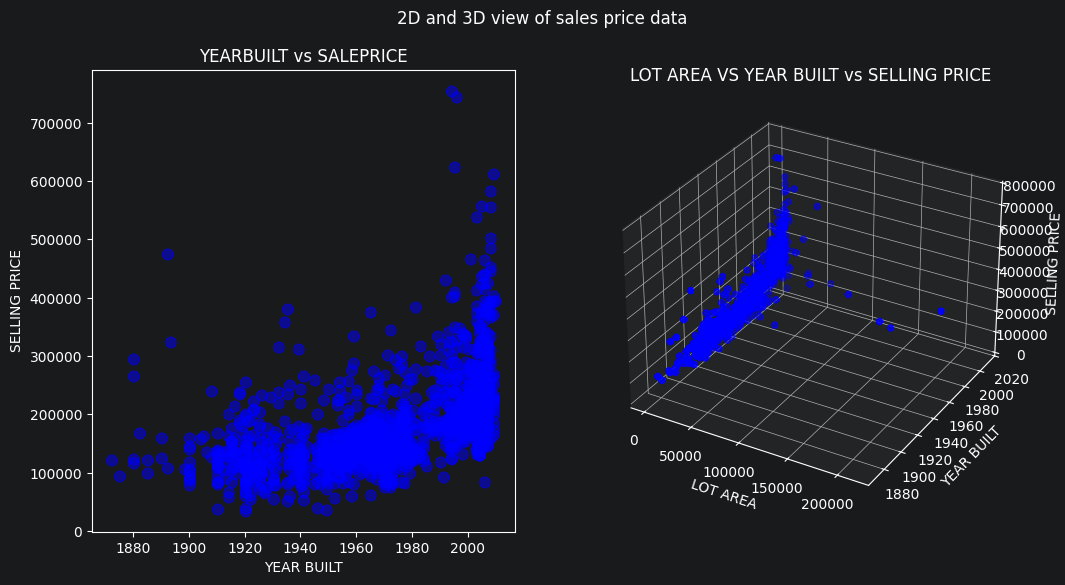

In [5]:
# 設定散佈圖的點面積大小
area = 60
# 取出建造年份作為 X 軸
x = df_pd['YEARBUILT']
# 取出售價作為 Y 軸（這是我們要預測的目標值）
y = df_pd['SALEPRICE']
# 取出土地面積作為 3D 圖的第三個維度
z = df_pd['LOTAREA']

# 建立寬 12 高 6 的畫布
fig = plt.figure(figsize=(12, 6))
fig.suptitle('2D and 3D view of sales price data')

# 左圖（2D 散佈圖）：觀察建造年份與售價的關係
ax = fig.add_subplot(1, 2, 1)
# 繪製散佈圖，alpha=0.5 讓重疊的點呈現半透明效果
ax.scatter(x, y, alpha=0.5, color='blue', s=area)
ax.set_xlabel('YEAR BUILT')
ax.set_ylabel('SELLING PRICE')
plt.title('YEARBUILT vs SALEPRICE')

# 右圖（3D 散佈圖）：同時觀察土地面積、建造年份、售價三者的立體關係
ax = fig.add_subplot(1, 2, 2, projection='3d')
ax.scatter(z, x, y, color='blue', marker='o')
ax.set_ylabel('YEAR BUILT')
ax.set_zlabel('SELLING PRICE')
ax.set_xlabel('LOT AREA')
plt.title('LOT AREA VS YEAR BUILT vs SELLING PRICE')

# 顯示圖表
plt.show()

## 6. 售價分佈分析

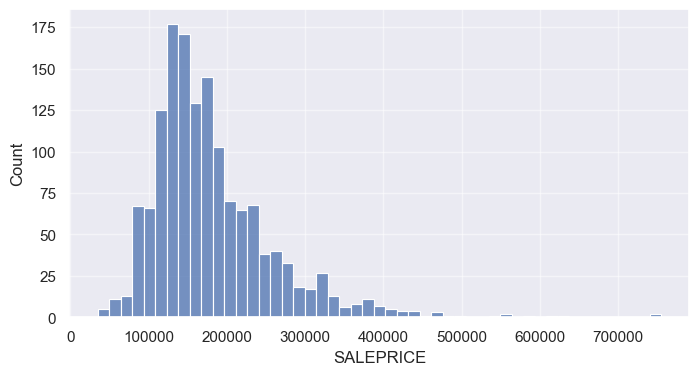

In [6]:
# 設定 seaborn 圖表大小為寬 8 高 4；固定隨機種子確保結果可重現
sns.set(rc={"figure.figsize": (8, 4)}); np.random.seed(0)
# 繪製售價（SALEPRICE）的直方圖，觀察售價的分佈是否為常態分佈
# 若分佈嚴重偏斜，可能需要做對數轉換等處理來提升模型效果
ax = sns.histplot(df_pd['SALEPRICE'])
# 顯示圖表
plt.show()

## 7. 檢視資料型態

In [7]:
# 印出每個欄位的資料型態（int64 = 整數、float64 = 浮點數、str/object = 文字類別）
# 這有助於後續決定哪些欄位要做數值標準化、哪些要做 one-hot 編碼
print("The dataset contains columns of the following data types : \n" + str(df_pd.dtypes))

The dataset contains columns of the following data types : 
ID              int64
LOTAREA         int64
BLDGTYPE          str
HOUSESTYLE        str
OVERALLCOND     int64
YEARBUILT       int64
ROOFSTYLE         str
EXTERCOND         str
FOUNDATION        str
BSMTCOND          str
HEATING           str
HEATINGQC         str
CENTRALAIR        str
ELECTRICAL        str
FULLBATH        int64
HALFBATH        int64
BEDROOMABVGR    int64
KITCHENABVGR    int64
KITCHENQUAL       str
TOTRMSABVGRD    int64
FIREPLACES      int64
FIREPLACEQU       str
GARAGETYPE        str
GARAGEFINISH      str
GARAGECARS      int64
GARAGECOND        str
POOLAREA        int64
POOLQC            str
FENCE             str
MOSOLD          int64
YRSOLD          int64
SALEPRICE       int64
dtype: object


## 8. 資料筆數與缺失值

In [8]:
# 印出每個欄位的非空資料筆數，若某欄位的數量明顯少於總筆數 1460，表示有缺失值
# 例如 POOLQC 只有 7 筆、FENCE 只有 281 筆，代表大部分房屋沒有泳池/圍籬
print("The dataset contains following number of records for each of the columns : \n" + str(df_pd.count()))

# 檢查每個欄位是否含有缺失值（True = 有缺失）
# 缺失值需要在前處理階段用 SimpleImputer 填補，否則模型無法訓練
df_pd.isnull().any()

The dataset contains following number of records for each of the columns : 
ID              1460
LOTAREA         1460
BLDGTYPE        1460
HOUSESTYLE      1460
OVERALLCOND     1460
YEARBUILT       1460
ROOFSTYLE       1460
EXTERCOND       1460
FOUNDATION      1460
BSMTCOND        1423
HEATING         1460
HEATINGQC       1460
CENTRALAIR      1460
ELECTRICAL      1459
FULLBATH        1460
HALFBATH        1460
BEDROOMABVGR    1460
KITCHENABVGR    1460
KITCHENQUAL     1460
TOTRMSABVGRD    1460
FIREPLACES      1460
FIREPLACEQU      770
GARAGETYPE      1379
GARAGEFINISH    1379
GARAGECARS      1460
GARAGECOND      1379
POOLAREA        1460
POOLQC             7
FENCE            281
MOSOLD          1460
YRSOLD          1460
SALEPRICE       1460
dtype: int64


ID              False
LOTAREA         False
BLDGTYPE        False
HOUSESTYLE      False
OVERALLCOND     False
YEARBUILT       False
ROOFSTYLE       False
EXTERCOND       False
FOUNDATION      False
BSMTCOND         True
HEATING         False
HEATINGQC       False
CENTRALAIR      False
ELECTRICAL       True
FULLBATH        False
HALFBATH        False
BEDROOMABVGR    False
KITCHENABVGR    False
KITCHENQUAL     False
TOTRMSABVGRD    False
FIREPLACES      False
FIREPLACEQU      True
GARAGETYPE       True
GARAGEFINISH     True
GARAGECARS      False
GARAGECOND       True
POOLAREA        False
POOLQC           True
FENCE            True
MOSOLD          False
YRSOLD          False
SALEPRICE       False
dtype: bool

## 9. 移除不需要的欄位

In [9]:
# 移除 ID 欄位，因為它只是流水編號，對預測售價沒有任何幫助
# axis=1 表示刪除的是欄（column），axis=0 則是刪除列（row）
df_pd = df_pd.drop(['ID'], axis=1)

# 顯示刪除 ID 後的前 5 筆資料，確認欄位已移除
df_pd.head()

,LOTAREA,BLDGTYPE,HOUSESTYLE,OVERALLCOND,YEARBUILT,ROOFSTYLE,EXTERCOND,FOUNDATION,BSMTCOND,HEATING,...,GARAGETYPE,GARAGEFINISH,GARAGECARS,GARAGECOND,POOLAREA,POOLQC,FENCE,MOSOLD,YRSOLD,SALEPRICE
0,8450,1Fam,2Story,5,2003,Gable,TA,PConc,TA,GasA,...,Attchd,RFn,2,TA,0,NaN,NaN,2,2008,208500
1,9600,1Fam,1Story,8,1976,Gable,TA,CBlock,TA,GasA,...,Attchd,RFn,2,TA,0,NaN,NaN,5,2007,181500
2,11250,1Fam,2Story,5,2001,Gable,TA,PConc,TA,GasA,...,Attchd,RFn,2,TA,0,NaN,NaN,9,2008,223500
3,9550,1Fam,2Story,5,1915,Gable,TA,BrkTil,Gd,GasA,...,Detchd,Unf,3,TA,0,NaN,NaN,2,2006,140000
4,14260,1Fam,2Story,5,2000,Gable,TA,PConc,TA,GasA,...,Attchd,RFn,3,TA,0,NaN,NaN,12,2008,250000


## 10. 類別特徵前處理

In [10]:
# 自動找出所有文字類型（str/object）的欄位，這些就是「類別特徵」
# 例如：BLDGTYPE（建築類型）、ROOFSTYLE（屋頂樣式）、HEATINGQC（暖氣品質）等
categoricalColumns = df_pd.select_dtypes(include=['str', 'object']).columns

# 印出類別欄位清單，確認哪些欄位會被做 one-hot 編碼
print("Categorical columns : ")
print(categoricalColumns)

# 建立缺失值填補器：用「出現最頻繁的值」來填補類別欄位的缺失值
# 例如 GARAGETYPE 缺失時，用最常見的車庫類型來填補
impute_categorical = SimpleImputer(strategy="most_frequent")
# 建立 one-hot 編碼器：將文字類別轉為數值向量，handle_unknown='ignore' 避免遇到未知類別時報錯
onehot_categorical = OneHotEncoder(handle_unknown='ignore')

# 將填補與編碼兩個步驟串成 Pipeline，確保執行順序正確
# 流程：缺失值填補 → one-hot 編碼
categorical_transformer = Pipeline(steps=[('impute', impute_categorical), ('onehot', onehot_categorical)])

Categorical columns : 
Index(['BLDGTYPE', 'HOUSESTYLE', 'ROOFSTYLE', 'EXTERCOND', 'FOUNDATION',
       'BSMTCOND', 'HEATING', 'HEATINGQC', 'CENTRALAIR', 'ELECTRICAL',
       'KITCHENQUAL', 'FIREPLACEQU', 'GARAGETYPE', 'GARAGEFINISH',
       'GARAGECOND', 'POOLQC', 'FENCE'],
      dtype='str')


## 11. 數值特徵前處理

In [11]:
# 找出所有數值型欄位（float 與 int），並排除目標變數 SALEPRICE
# 這些數值特徵（如 LOTAREA、YEARBUILT、GARAGECARS 等）需要做標準化
numericalColumns = [col for col in df_pd.select_dtypes(include=[float, int]).columns if col not in ['SALEPRICE']]
# 印出數值欄位清單
print("Numerical columns : ")
print(numericalColumns)

# 建立標準化轉換器：將數值縮放為平均值=0、標準差=1 的標準常態分佈
# 這能避免數值範圍差異太大（如 LOTAREA 上萬 vs FULLBATH 只有 0-3）影響模型判斷
scaler_numerical = StandardScaler()

# 將標準化步驟包成 Pipeline（目前只有一步，但保持結構一致性）
numerical_transformer = Pipeline(steps=[('scale', scaler_numerical)])

Numerical columns : 
['LOTAREA', 'OVERALLCOND', 'YEARBUILT', 'FULLBATH', 'HALFBATH', 'BEDROOMABVGR', 'KITCHENABVGR', 'TOTRMSABVGRD', 'FIREPLACES', 'GARAGECARS', 'POOLAREA', 'MOSOLD', 'YRSOLD']


## 12. 建立 ColumnTransformer

In [12]:
# 建立「僅處理類別欄位」的 ColumnTransformer
# remainder="passthrough" 表示沒被指定處理的欄位（數值欄位）直接保留不動
preprocessorForCategoricalColumns = ColumnTransformer(
    transformers=[('cat', categorical_transformer, categoricalColumns)],
    remainder="passthrough")

# 建立「同時處理類別與數值欄位」的 ColumnTransformer
# 類別欄位 → 填補缺失值 + one-hot 編碼；數值欄位 → 標準化
# remainder="passthrough" 保留其餘未指定的欄位（如 SALEPRICE）
preprocessorForAllColumns = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categoricalColumns),
        ('num', numerical_transformer, numericalColumns)
    ],
    remainder="passthrough")

# 以下為示範：先單獨執行轉換，觀察轉換後的資料長什麼樣子
# 實際建模時，轉換會在 Pipeline 中自動執行，不需要手動呼叫

# 示範一：僅轉換類別欄位後的資料
df_pd_temp = preprocessorForCategoricalColumns.fit_transform(df_pd)
print("Data after transforming :")
print(df_pd_temp)

# 示範二：類別 + 數值欄位全部轉換後的資料
df_pd_temp_2 = preprocessorForAllColumns.fit_transform(df_pd)
print("Data after transforming :")
print(df_pd_temp_2)

Data after transforming :
[[1.00000e+00 0.00000e+00 0.00000e+00 ... 2.00000e+00 2.00800e+03
  2.08500e+05]
 [1.00000e+00 0.00000e+00 0.00000e+00 ... 5.00000e+00 2.00700e+03
  1.81500e+05]
 [1.00000e+00 0.00000e+00 0.00000e+00 ... 9.00000e+00 2.00800e+03
  2.23500e+05]
 ...
 [1.00000e+00 0.00000e+00 0.00000e+00 ... 5.00000e+00 2.01000e+03
  2.66500e+05]
 [1.00000e+00 0.00000e+00 0.00000e+00 ... 4.00000e+00 2.01000e+03
  1.42125e+05]
 [1.00000e+00 0.00000e+00 0.00000e+00 ... 6.00000e+00 2.00800e+03
  1.47500e+05]]
Data after transforming :
[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 ... -1.59911110e+00
   1.38777489e-01  2.08500000e+05]
 [ 1.00000000e+00  0.00000000e+00  0.00000000e+00 ... -4.89110051e-01
  -6.14438622e-01  1.81500000e+05]
 [ 1.00000000e+00  0.00000000e+00  0.00000000e+00 ...  9.90891347e-01
   1.38777489e-01  2.23500000e+05]
 ...
 [ 1.00000000e+00  0.00000000e+00  0.00000000e+00 ... -4.89110051e-01
   1.64520971e+00  2.66500000e+05]
 [ 1.00000000e+00  0.00000000e+

## 13. 定義特徵與標籤

In [13]:
# === 準備將資料拆分為「特徵」與「標籤」 ===

# 初始化 features 變數（此行會被下一行覆蓋，僅為程式碼慣例）
features = []
# 將 SALEPRICE 以外的所有欄位作為輸入特徵（X）
# 這些特徵包含房屋的各項屬性，用來預測售價
features = df_pd.drop(['SALEPRICE'], axis=1)

# 將 SALEPRICE 欄位取出作為標籤（y），即模型要預測的目標值
label = pd.DataFrame(df_pd, columns=['SALEPRICE'])
# 直接取出 Series 格式的標籤（覆蓋上一行的 DataFrame 格式）
label = df_pd['SALEPRICE']

# 印出標籤內容，確認目標值正確
print(" value of label : " + str(label))

 value of label : 0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SALEPRICE, Length: 1460, dtype: int64


## 14. 簡單線性迴歸 — 建模與預測

In [14]:
# ===== 簡單線性迴歸（Simple Linear Regression）=====
# 只使用「建造年份」這一個特徵來預測售價，觀察單一變數的預測能力

# 取出 YEARBUILT 欄位並轉為二維陣列（sklearn 要求輸入為 2D）
X = features['YEARBUILT'].values.reshape(-1, 1)
# 將資料拆分為 75% 訓練集、25% 測試集，random_state=0 確保每次拆分結果相同
X_train_slr, X_test_slr, y_train_slr, y_test_slr = train_test_split(X, label, random_state=0)

# 印出訓練集與測試集的維度，確認資料拆分正確
print("Dimensions of datasets that will be used for training : Input features" + str(X_train_slr.shape) +
      " Output label" + str(y_train_slr.shape))
print("Dimensions of datasets that will be used for testing : Input features" + str(X_test_slr.shape) +
      " Output label" + str(y_test_slr.shape))

# 匯入線性迴歸模型
from sklearn.linear_model import LinearRegression

# 設定模型名稱（用於圖表標題顯示）
model_name = 'Simple Linear Regression'

# 建立簡單線性迴歸模型實例
slRegressor = LinearRegression()

# 用訓練資料擬合模型（找出最佳的斜率與截距）
slRegressor.fit(X_train_slr, y_train_slr)

# 用測試資料的特徵進行預測，得到預測售價
y_pred_slr = slRegressor.predict(X_test_slr)

# 印出模型物件資訊
print(slRegressor)

# 印出截距（intercept）：當 YEARBUILT = 0 時的預測售價基準值
print('Intercept: \n', slRegressor.intercept_)
# 印出係數（coefficient）：YEARBUILT 每增加 1 年，售價預計變動多少
print('Coefficients: \n', slRegressor.coef_)

Dimensions of datasets that will be used for training : Input features(1095, 1) Output label(1095,)
Dimensions of datasets that will be used for testing : Input features(365, 1) Output label(365,)
LinearRegression()
Intercept: 
 -2517567.321538113
Coefficients: 
 [1368.99630631]


## 15. 簡單線性迴歸 — 評估

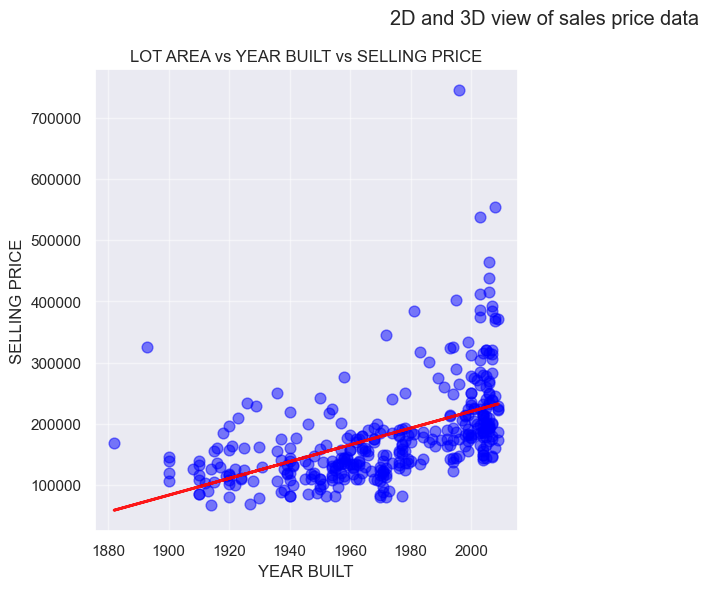

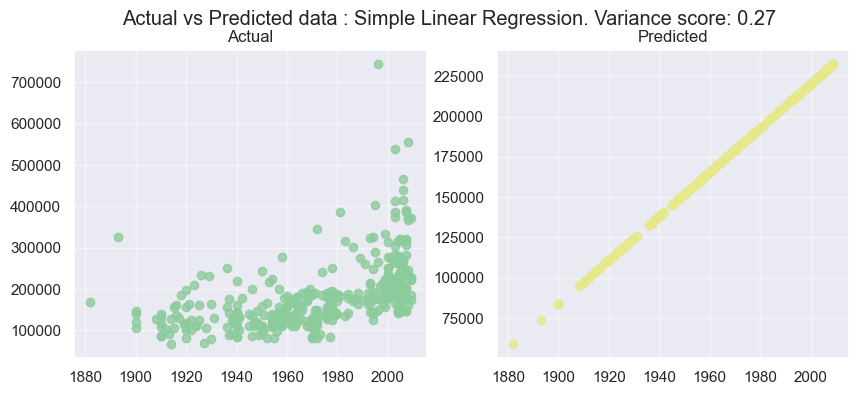

Mean squared error: 4830018416.25
R2 score: 0.27


In [15]:
# 繪製 2D 與 3D 對比圖：觀察預測線（紅色）與實際散佈點（藍色）的吻合程度
# isLinear=True 表示只顯示 2D 圖（簡單線性迴歸只有一個特徵，無法畫 3D）
two_vs_three(X_test_slr[:, 0], y_test_slr, y_pred_slr, None, True)

# 繪製實際值 vs 預測值的並排散佈圖，直觀比較兩者分佈是否一致
two_d_compare(X_test_slr, y_test_slr, y_pred_slr, model_name)

# 計算並印出 MSE 與 R²，同時將結果儲存供最後的模型比較使用
slrMetrics = model_metrics(slRegressor, y_test_slr, y_pred_slr)

## 16. 多元線性迴歸 — 建模與預測

In [16]:
# ===== 多元線性迴歸（Multiple Linear Regression）=====
# 使用所有特徵（30 個）來預測售價，觀察多變數是否能提升預測準確度

# 將全部特徵拆分為訓練集與測試集（75/25 比例）
X_train, X_test, y_train, y_test = train_test_split(features, label, random_state=0)

# 印出訓練集與測試集的維度
print("Dimensions of datasets that will be used for training : Input features" + str(X_train.shape) +
      " Output label" + str(y_train.shape))
print("Dimensions of datasets that will be used for testing : Input features" + str(X_test.shape) +
      " Output label" + str(y_test.shape))

# 匯入線性迴歸模型
from sklearn.linear_model import LinearRegression

# 設定模型名稱
model_name = 'Multiple Linear Regression'

# 建立多元線性迴歸模型實例
mlRegressor = LinearRegression()

# 建立 Pipeline：先做資料前處理（類別編碼 + 數值標準化），再進行迴歸訓練
# Pipeline 確保訓練與預測時使用相同的前處理邏輯，避免資料洩漏
mlr_model = Pipeline(steps=[('preprocessorAll', preprocessorForAllColumns), ('regressor', mlRegressor)])

# 用訓練資料擬合整條 Pipeline（前處理 + 模型訓練一次完成）
mlr_model.fit(X_train, y_train)

# 用測試資料進行預測（Pipeline 會自動先做前處理再預測）
y_pred_mlr = mlr_model.predict(X_test)

# 印出模型物件資訊
print(mlRegressor)

# 印出截距與各特徵的係數（每個特徵對售價的影響權重）
print('Intercept: \n', mlRegressor.intercept_)
print('Coefficients: \n', mlRegressor.coef_)

Dimensions of datasets that will be used for training : Input features(1095, 30) Output label(1095,)
Dimensions of datasets that will be used for testing : Input features(365, 30) Output label(365,)
LinearRegression()
Intercept: 
 156627.4204332493
Coefficients: 
 [  6267.87762611   2479.02414029   8797.73682332 -13253.10280371
  -4291.53578601   1191.535428    10629.88326392   3704.92868167
   7521.17938534 -12518.89284555  -5642.12349275   1823.79826104
  -6710.30868167   5056.58738348 -10078.5923191   -5922.44615431
   8873.17819182  -5356.73886612   7428.01176423 -19881.67837283
   1752.31386936   4020.69343405  15527.12401852  -1418.4529491
  -8023.33503413 -12920.48700529   -898.64229306 -35266.89648222
   4057.40469667  53051.95611803 -11175.90971138  -5573.40920826
  20792.49758601  -4043.17866636 -30149.1652352   -1634.62606953
  15688.54691618  -5180.43106563  42447.99945794 -21172.32400375
  13082.87697853   5137.82260514   6216.23012462 -33753.80869668
   9316.8789884    16

## 17. 多元線性迴歸 — 評估

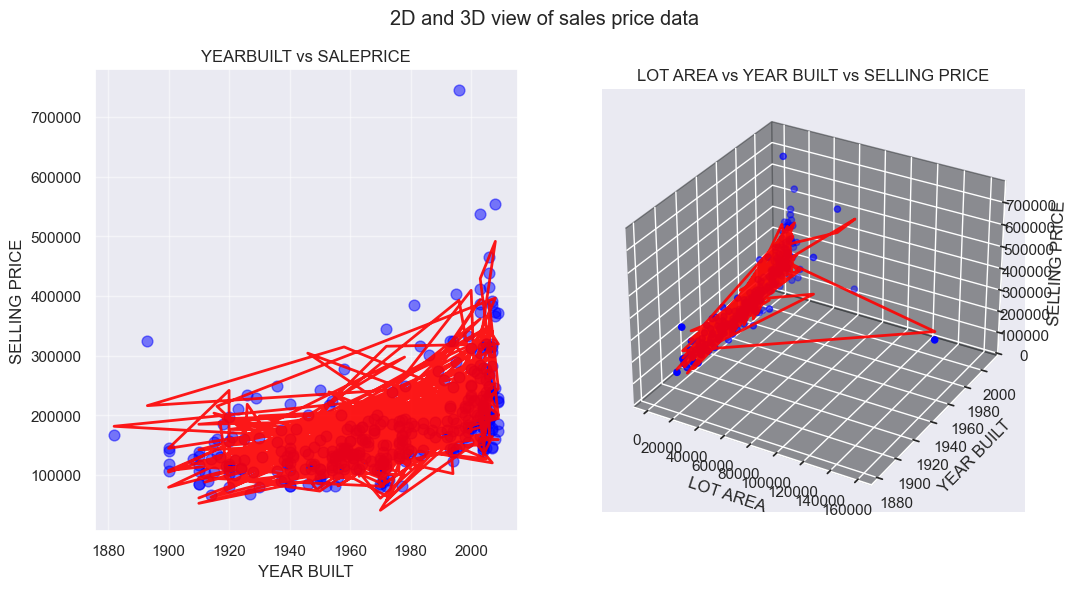

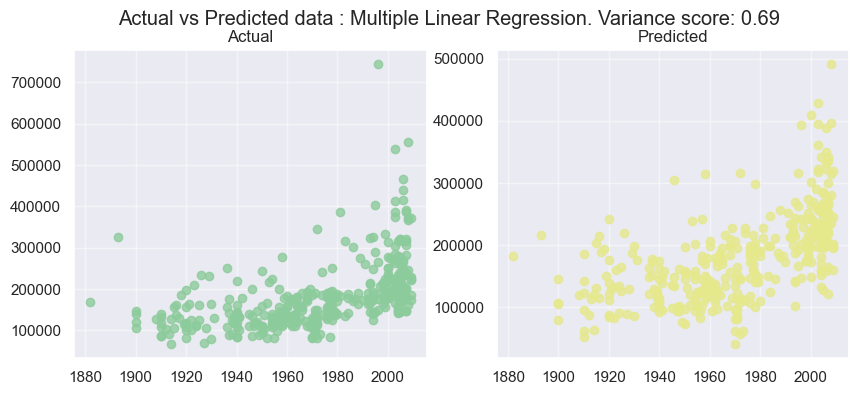

Mean squared error: 2041070045.89
R2 score: 0.69


In [17]:
# 繪製 2D 與 3D 對比圖：以 YEARBUILT 為 X 軸、LOTAREA 為 Z 軸觀察預測效果
two_vs_three(X_test['YEARBUILT'], y_test, y_pred_mlr, X_test['LOTAREA'], False)

# 繪製實際值 vs 預測值的並排散佈圖
two_d_compare(X_test['YEARBUILT'], y_test, y_pred_mlr, model_name)

# 計算 MSE 與 R²，儲存結果供最後比較
mlrMetrics = model_metrics(slRegressor, y_test, y_pred_mlr)

## 18. 多項式迴歸 — 建模與預測

In [18]:
# ===== 多項式迴歸（Polynomial Linear Regression）=====
# 使用 LOTAREA 與 YEARBUILT 兩個特徵，透過多項式展開捕捉非線性關係
# 線性迴歸只能畫直線，但房價與年份的關係可能是曲線，多項式迴歸能處理這種情況

# 取出第 0 欄（LOTAREA）與第 4 欄（YEARBUILT）作為特徵
X = features.iloc[:, [0, 4]].values
# 拆分訓練集與測試集
X_train, X_test, y_train, y_test = train_test_split(X, label, random_state=0)

# 印出資料維度
print("Dimensions of datasets that will be used for training : Input features" + str(X_train.shape) +
      " Output label" + str(y_train.shape))
print("Dimensions of datasets that will be used for testing : Input features" + str(X_test.shape) +
      " Output label" + str(y_test.shape))

# 匯入線性迴歸與多項式特徵轉換器
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 設定模型名稱
model_name = 'Polynomial Linear Regression'

# 建立 3 次多項式特徵轉換器：將 [x1, x2] 展開為 [1, x1, x2, x1², x1·x2, x2², x1³, ...]
polynomial_features = PolynomialFeatures(degree=3)
# 建立線性迴歸模型（在多項式特徵空間中做線性迴歸）
plRegressor = LinearRegression()

# 建立 Pipeline：先做多項式特徵展開，再用線性迴歸擬合
plr_model = Pipeline(steps=[('polyFeature', polynomial_features), ('regressor', plRegressor)])

# 用訓練資料擬合模型
plr_model.fit(X_train, y_train)

# 用測試資料進行預測
y_pred_plr = plr_model.predict(X_test)

# 印出模型物件資訊
print(plRegressor)

# 印出截距與多項式展開後各項的係數
print('Intercept: \n', plRegressor.intercept_)
print('Coefficients: \n', plRegressor.coef_)

Dimensions of datasets that will be used for training : Input features(1095, 2) Output label(1095,)
Dimensions of datasets that will be used for testing : Input features(365, 2) Output label(365,)
LinearRegression()
Intercept: 
 28127676.490234543
Coefficients: 
 [ 0.00000000e+00  5.95354305e-02 -1.13905623e-02  1.84004653e-03
 -6.19684950e-02 -2.22555406e+01  2.97055839e-10 -9.85643642e-07
  3.37404549e-05  7.62862508e-03]


## 19. 多項式迴歸 — 評估

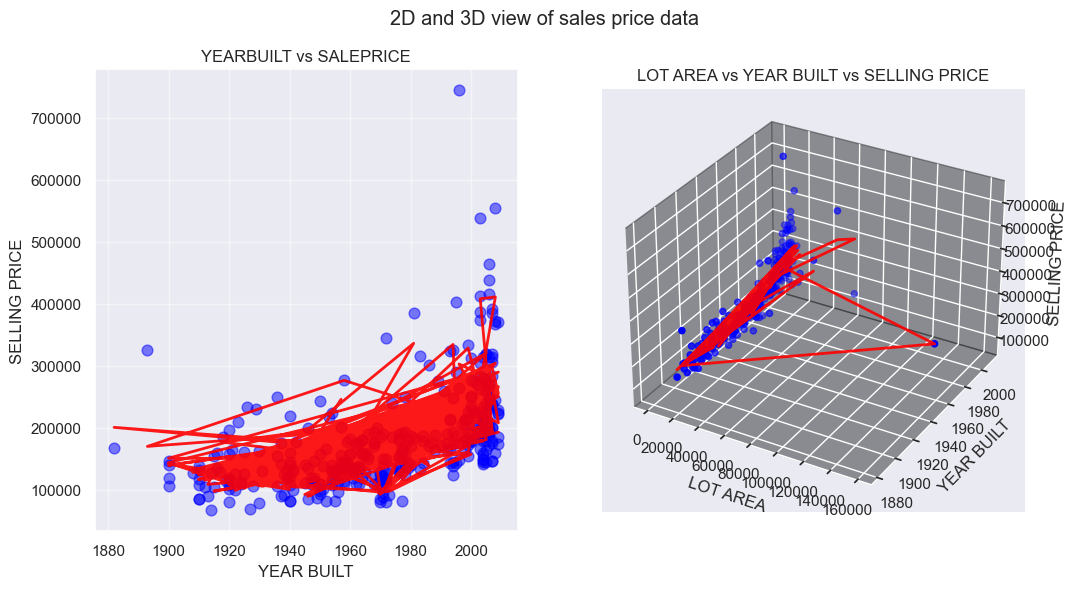

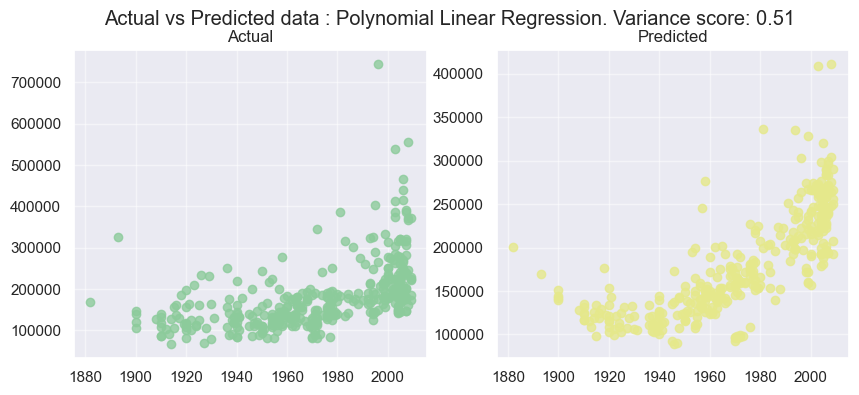

Mean squared error: 3253974918.12
R2 score: 0.51


In [19]:
# 繪製 2D 與 3D 對比圖：X 軸為 YEARBUILT（第 1 欄）、Z 軸為 LOTAREA（第 0 欄）
two_vs_three(X_test[:, 1], y_test, y_pred_plr, X_test[:, 0], False)

# 繪製實際值 vs 預測值的並排散佈圖
two_d_compare(X_test[:, 1], y_test, y_pred_plr, model_name)

# 計算 MSE 與 R²，儲存結果供最後比較
plrMetrics = model_metrics(plRegressor, y_test, y_pred_plr)

## 20. 決策樹迴歸 — 建模與預測

In [20]:
# ===== 決策樹迴歸（Decision Tree Regressor）=====
# 決策樹透過一連串的「如果...就...」規則來做預測，不需要假設資料是線性關係

# 重新拆分訓練/測試集（使用全部特徵）
X_train, X_test, y_train, y_test = train_test_split(features, df_pd['SALEPRICE'], random_state=0)

# 印出資料維度
print("Dimensions of datasets that will be used for training : Input features" + str(X_train.shape) +
      " Output label" + str(y_train.shape))
print("Dimensions of datasets that will be used for testing : Input features" + str(X_test.shape) +
      " Output label" + str(y_test.shape))

# 匯入決策樹迴歸器
from sklearn.tree import DecisionTreeRegressor

# 設定模型名稱
model_name = "Decision Tree Regressor"

# 建立決策樹模型：random_state=0 確保可重現，max_features=30 限制每次分裂考慮的特徵數
decisionTreeRegressor = DecisionTreeRegressor(random_state=0, max_features=30)

# 建立 Pipeline：先做前處理（類別編碼 + 數值標準化），再用決策樹訓練
dtr_model = Pipeline(steps=[('preprocessorAll', preprocessorForAllColumns), ('regressor', decisionTreeRegressor)])

# 用訓練資料擬合模型
dtr_model.fit(X_train, y_train)

# 用測試資料進行預測
y_pred_dtr = dtr_model.predict(X_test)

# 印出模型物件資訊
print(decisionTreeRegressor)

# 將決策樹結構匯出為 .dot 格式的圖形描述檔
export_graphviz(decisionTreeRegressor, out_file='tree.dot')
# 從 .dot 檔讀取圖形結構
(graph,) = pydot.graph_from_dot_file('tree.dot')
# 將決策樹渲染為 PNG 圖片，方便觀察樹的分裂規則
graph.write_png('tree.png')

Dimensions of datasets that will be used for training : Input features(1095, 30) Output label(1095,)
Dimensions of datasets that will be used for testing : Input features(365, 30) Output label(365,)
DecisionTreeRegressor(max_features=30, random_state=0)


## 21. 決策樹迴歸 — 評估

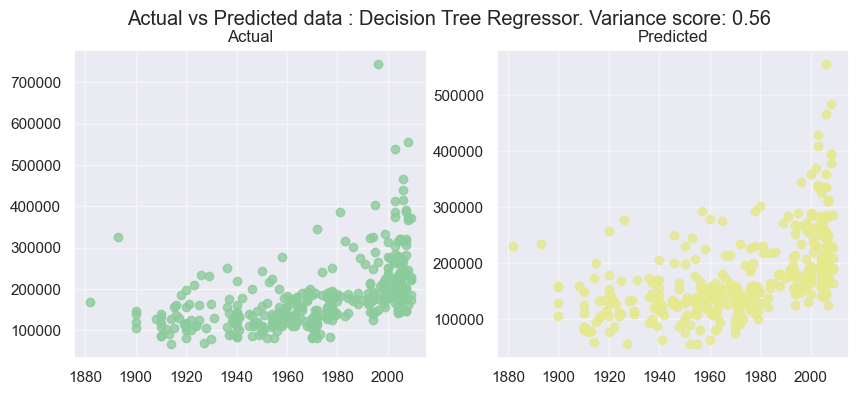

Mean squared error: 2912093284.03
R2 score: 0.56


In [21]:
# 繪製實際值 vs 預測值的並排散佈圖，觀察決策樹的預測效果
two_d_compare(X_test['YEARBUILT'], y_test, y_pred_dtr, model_name)

# 計算 MSE 與 R²，儲存結果供最後比較
dtrMetrics = model_metrics(decisionTreeRegressor, y_test, y_pred_dtr)

## 22. 隨機森林迴歸 — 建模與評估

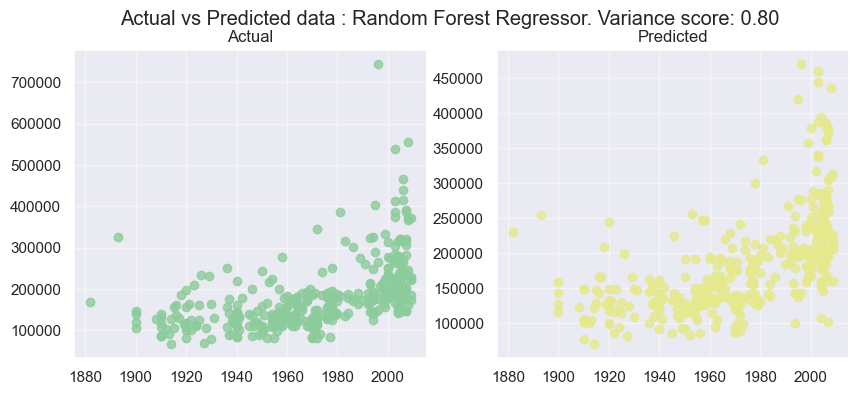

Mean squared error: 1320832739.58
R2 score: 0.80


In [22]:
# ===== 隨機森林迴歸（Random Forest Regressor）=====
# 隨機森林 = 多棵決策樹投票取平均，能有效降低單一決策樹的過擬合問題

# 匯入隨機森林迴歸器
from sklearn.ensemble import RandomForestRegressor

# 設定模型名稱
model_name = "Random Forest Regressor"

# 建立隨機森林模型：
# n_estimators=100：建立 100 棵決策樹
# max_depth=15：每棵樹最多 15 層深度，防止過度擬合
# random_state=0：確保結果可重現
randomForestRegressor = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=0)

# 建立 Pipeline：先做前處理，再用隨機森林訓練
rfr_model = Pipeline(steps=[('preprocessorAll', preprocessorForAllColumns), ('regressor', randomForestRegressor)])

# 用訓練資料擬合模型
rfr_model.fit(X_train, y_train)

# 用測試資料進行預測
y_pred_rfr = rfr_model.predict(X_test)

# 繪製實際值 vs 預測值的並排散佈圖
two_d_compare(X_test['YEARBUILT'], y_test, y_pred_rfr, model_name)

# 計算 MSE 與 R²，儲存結果供最後比較
rfrMetrics = model_metrics(randomForestRegressor, y_test, y_pred_rfr)

## 23. 模型效能比較

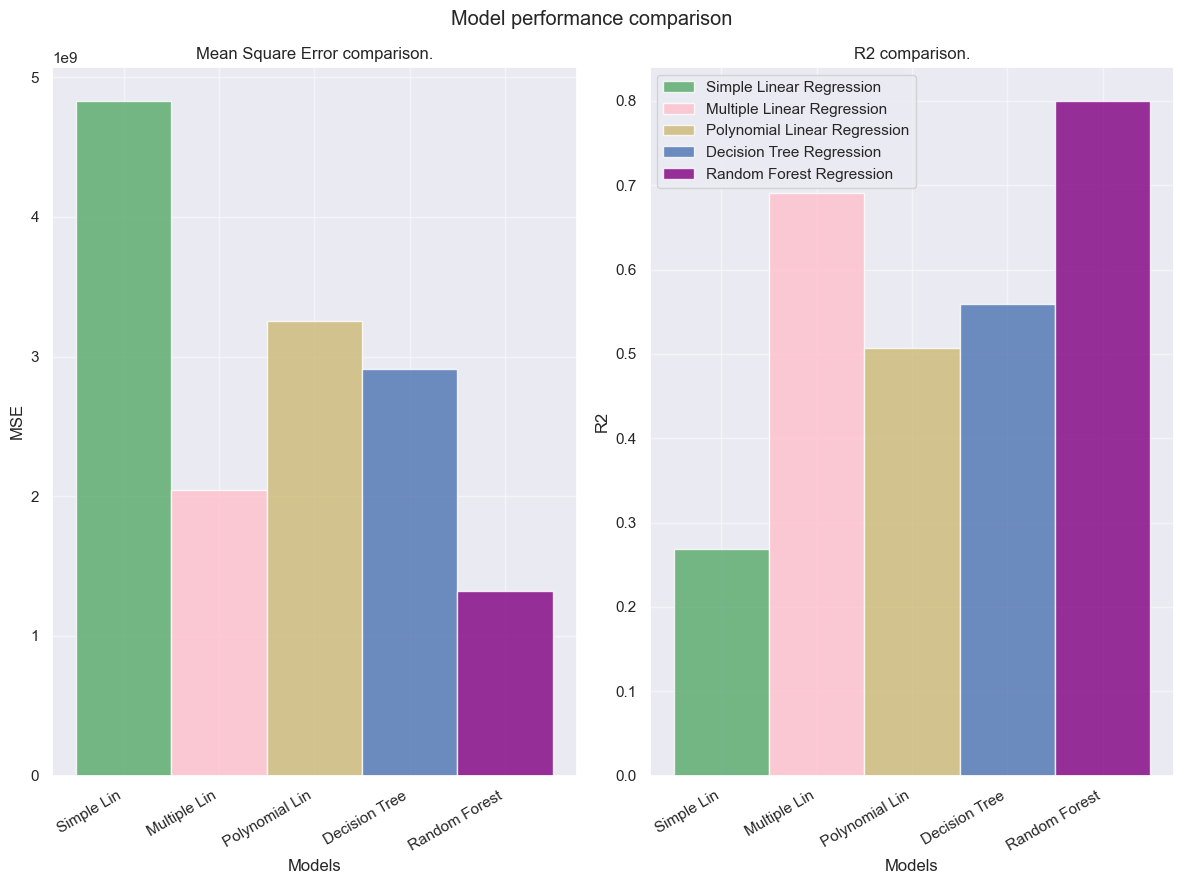

In [23]:
# ===== 五種迴歸模型效能比較 =====
# 將所有模型的 MSE 與 R² 用長條圖並排顯示，一目了然哪個模型最好

# 設定長條圖的基本參數
n_groups = 1                          # 每個模型各一組長條
index = np.arange(n_groups)           # X 軸的基準位置
bar_width = 1                         # 每個長條的寬度
opacity = 0.8                         # 長條的透明度
# 設定 5 個模型的 X 軸刻度位置（間隔為 bar_width）
tick_positions = [i * bar_width for i in range(5)]
# 設定 5 個模型的 X 軸標籤名稱
tick_labels = ['Simple Lin', 'Multiple Lin', 'Polynomial Lin', 'Decision Tree', 'Random Forest']

area = 60
# 建立左右兩個子圖（左：MSE 比較、右：R² 比較）
plt.subplots(ncols=2, figsize=(12, 9))
plt.suptitle('Model performance comparison')

# ===== 左圖：MSE（均方誤差）比較 =====
# MSE 越小代表預測越準確
ax1 = plt.subplot(121)

# 依序繪製 5 種模型的 MSE 長條（各用不同顏色區分）
rects1 = plt.bar(index, slrMetrics[0], bar_width,
alpha=opacity, color='g', label='Simple Linear Regression')

rects2 = plt.bar(index + bar_width, mlrMetrics[0], bar_width,
alpha=opacity, color='pink', label='Multiple Linear Regression')

rects3 = plt.bar(index + bar_width*2, plrMetrics[0], bar_width,
alpha=opacity, color='y', label='Polynomial Linear Regression')

rects4 = plt.bar(index + bar_width*3, dtrMetrics[0], bar_width,
alpha=opacity, color='b', label='Decision Tree Regression')

rects6 = plt.bar(index + bar_width*4, rfrMetrics[0], bar_width,
alpha=opacity, color='purple', label='Random Forest Regression')

plt.xlabel('Models')
plt.ylabel('MSE')
plt.title('Mean Square Error comparison.')
# 設定 X 軸刻度位置與標籤
ax1.set_xticks(tick_positions)
ax1.set_xticklabels(tick_labels, rotation=30, ha='right')

# ===== 右圖：R²（決定係數）比較 =====
# R² 越接近 1 代表模型解釋能力越強
ax2 = plt.subplot(122)

# 依序繪製 5 種模型的 R² 長條
rects1 = plt.bar(index, slrMetrics[1], bar_width,
alpha=opacity, color='g', label='Simple Linear Regression')

rects2 = plt.bar(index + bar_width, mlrMetrics[1], bar_width,
alpha=opacity, color='pink', label='Multiple Linear Regression')

rects3 = plt.bar(index + bar_width*2, plrMetrics[1], bar_width,
alpha=opacity, color='y', label='Polynomial Linear Regression')

rects4 = plt.bar(index + bar_width*3, dtrMetrics[1], bar_width,
alpha=opacity, color='b', label='Decision Tree Regression')

rects6 = plt.bar(index + bar_width*4, rfrMetrics[1], bar_width,
alpha=opacity, color='purple', label='Random Forest Regression')

plt.xlabel('Models')
plt.ylabel('R2')
plt.title('R2 comparison.')
# 設定 X 軸刻度位置與標籤
ax2.set_xticks(tick_positions)
ax2.set_xticklabels(tick_labels, rotation=30, ha='right')

# 顯示圖例說明各顏色代表哪個模型
plt.legend()
# 自動調整子圖間距，避免標籤被裁切
plt.tight_layout()
# 顯示圖表
plt.show()

<p><font size=-1 color=gray>
&copy; Copyright 2019 IBM Corp. All Rights Reserved.
<p>
Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file
except in compliance with the License. You may obtain a copy of the License at
https://www.apache.org/licenses/LICENSE-2.0
Unless required by applicable law or agreed to in writing, software distributed under the
License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either
express or implied. See the License for the specific language governing permissions and
limitations under the License.
</font></p>